<a href="https://colab.research.google.com/github/kaansoftware34/softito_calismalar_face2face/blob/main/llm_veri_%C3%B6n_i%C5%9Fleme_ipynb_170626_e_ticaret_%C3%B6rnek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM'ler için Veri Ön İşleme ve Girdi Hazırlama

Bu notebook'ta **LLM (Large Language Model)** eğitimi ve ince ayar (fine-tuning) için **veri ön işleme** ve **girdi hazırlama** adımlarını detaylıca inceleyeceğiz.

---
## Konu Başlıkları
1. **Giriş:** LLM'ler neden özel veri hazırlığı gerektirir?
2. **Metin Temizleme (Text Cleaning)** – Gürültü temizleme, normalizasyon
3. **Tokenization** – Word-level, Subword (BPE, WordPiece, Unigram)
4. **Padding, Truncation & Attention Mask** – Batch işleme hazırlık
5. **Instruction Formatı** – Fine-tuning için girdi/çıktı şablonları
6. **Hugging Face Tokenizer & Dataset** ile uygulamalı örnek
7. **Görsel Etkileşimli Demo** – ipywidgets ile canlı deneyim

> Her kod satırı açıklamalıdır. Anlamadığınız yerde durup okuyabilirsiniz.

In [ ]:
# ============================================================
# GEREKLİ KÜTÜPHANELERİ YÜKLE
# ============================================================

# Bu hücrede tüm bağımlılıkları yüklüyoruz.
# transformers: Hugging Face'in tokenizer ve model kütüphanesi
# datasets:   Hugging Face'in veri seti kütüphanesi
# ipywidgets: Jupyter'da etkileşimli arayüz (slider, buton vb.)
# IPython:    Görsel/zengin çıktılar için (display, HTML)

!pip install -q transformers datasets ipywidgets

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


In [ ]:
# ============================================================
# KÜTÜPHANELERİ İÇE AKTAR
# ============================================================

import re                               # Regular expression: metin temizleme için
import pandas as pd                     # Veri çerçevesi (tabular veri) için
import numpy as np                      # Sayısal işlemler için
import matplotlib.pyplot as plt         # Grafik çizimi için
from transformers import AutoTokenizer  # Hugging Face tokenizer sınıfı
from datasets import Dataset            # Hugging Face veri seti sınıfı
import warnings                         # Uyarıları bastırmak için
warnings.filterwarnings('ignore')       # Gereksiz uyarıları kapat

# ipywidgets: etkileşimli arayüz bileşenleri
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

print("Tüm kütüphaneler içe aktarıldı.")

Tüm kütüphaneler içe aktarıldı.


---
## 1. Metin Temizleme (Text Cleaning)

LLM'e verdiğimiz ham metinler genellikle gürültülüdür:
- HTML etiketleri, URL'ler, emojiler, özel karakterler
- Fazla boşluklar, kontrol karakterleri
- Tutarsız büyük/küçük harf kullanımı

**Neden önemli?**
- Tokenizer gereksiz token'lar üretir → context window'u boşa harcar
- Model anlamsız desenler öğrenebilir → performans düşer
- Vocabulary şişer → bellek ve hız sorunu

In [ ]:
# ============================================================
# ÖRNEK HAM METİNLER (E-TİCARET / MÜŞTERİ YORUMLARI)
# ============================================================
from IPython.display import display, HTML

# LLM ön işlemede karşılaşabileceğimiz tipik ham metin örnekleri
raw_texts = [
    "Kargo çok hızlıydı, ürün elime sağlam ulaştı.😊 Teşekkürler!",          # emoji içeriyor
    "Bu   telefonun   kamerası   beklediğimden   kötü!!!",                          # fazla boşluk
    '<p>Ürün açıklamasında yazan özellikler eksik.</p>\n<br/>İade edeceğim',                            # HTML etiketi
    "Sipariş tutarı: $199.99, Kargo: BEDAVA >> ŞİMDİ SİPARİŞ VER!",                                 # özel karakterler
    "Detaylar için: https://magaza.example.com/urun-123 veya http://destek.org",                        # URL'ler
    "Harika bir ayakkabı!! Tam numaramı aldım??? Çok rahat!!! :)",                                       # tekrarlayan noktalama
]

# Her bir metni ekrana basalım, index numarasıyla
for i, text in enumerate(raw_texts):
    # display: zengin (rich) çıktı için; HTML ile renklendiriyoruz
    display(HTML(f"<b>[{i}]</b> <span style='color:gray;'>{text}</span>"))

In [ ]:
# ============================================================
# FARKLI TÜRDE GÜRÜLTÜLÜ METİN ÖRNEKLERİ
# ============================================================

more_raw_texts = [
    "Lütfen bana info@test-mail.com adresinden veya @destek hesabından ulaşın.", # E-posta ve etiketler
    "{\"kullanici\": \"ali\", \"mesaj\": \"sisteme giremiyorum!!\"}",            # JSON/Log kalıntıları
    "T&uuml;rkiye&#39;nin ba&#351;kenti Ankara&#39;d&imath;r.",                 # HTML entity / Encoding hataları
    "Telefon: +90 (555) 123-45-67    Tarih: 12.05.2024",                        # Karmaşık numaralar ve gereksiz boşluklar
    "ŞİMDİ AL!!!! %50 İNDİRİM KAÇMAAAAAZ 🚀🚀🔥🔥",                             # Spam tarzı, emojiler, tekrarlayan harfler/noktalama
    "\n\n\t\tBu cümlede\t\tgereksiz\t\t\t tab ve satır atlamaları var.\n\n"     # Kontrol karakterleri (tab, newline)
]

print("DAHA FAZLA GÜRÜLTÜLÜ METİN ÖRNEĞİ:\n")
for i, text in enumerate(more_raw_texts):
    display(HTML(f"<b>[{i}]</b> <span style='color:gray;'>{text}</span>"))


DAHA FAZLA GÜRÜLTÜLÜ METİN ÖRNEĞİ:



In [ ]:
# ============================================================
# SOSYAL MEDYA, OCR VE DİĞER GÜRÜLTÜ TÜRLERİ
# ============================================================

even_more_texts = [
    "@kullanici123 harika bir gün! #yapayzeka #llm #gelecek 🚀🤖",                 # Sosyal medya etiketleri ve hashtagler
    "Tükiy3'nin başk3nti Ank2ra'dır.",                                              # OCR (Optik Karakter Tanıma) okuma hataları
    "```python\nprint('merhaba')\n```\nYukarıdaki kodu çalıştırın.",               # Metin içine karışmış Markdown ve kod blokları
    "Abonelikten çıkmak için buraya tıklayın. Gizlilik Politikası. Kullanım Şartları.", # Web sitelerinden kazınmış (scraping) alt bilgi (boilerplate)
    "    b a ş l ı k    k e l i m e s i    ",                                       # Kelimeler arası anlamsız boşluklar
    "____________________________________________________\nBölüm 2'ye geçiyoruz."     # Metni bölmek için kullanılan anlamsız karakter çizgileri
]

print("SOSYAL MEDYA VE OCR GİBİ FARKLI GÜRÜLTÜLER:\n")
for i, text in enumerate(even_more_texts):
    display(HTML(f"<b>[{i}]</b> <span style='color:gray;'>{text}</span>"))

SOSYAL MEDYA VE OCR GİBİ FARKLI GÜRÜLTÜLER:



In [ ]:
# ============================================================
# METİN TEMİZLEME FONKSİYONU
# ============================================================

# Her satırda ne yaptığımızı açıklayarak ilerliyoruz.

def clean_text(text: str) -> str:
    """
    Ham metni LLM girdisine hazır hale getirir.

    Parametre:
        text (str): Temizlenecek ham metin

    Dönüş:
        str: Temizlenmiş metin
    """

    # --- Adım 1: HTML etiketlerini temizle ---
    # re.sub(pattern, replacement, string): regex ile değiştirme yapar
    # r'<[^>]+>': '<' ile başlayan, '>' ile biten, içinde '>' olmayan her şeyi bulur
    text = re.sub(r'<[^>]+>', '', text)

    # --- Adım 2: URL'leri temizle ---
    # http:// veya https:// ile başlayan URL'leri bul ve sil
    text = re.sub(r'https?://\S+', '', text)

    # --- Adım 3: Emoji ve özel sembolleri temizle ---
    # Unicode kategorilerini kullanarak emoji/ sembol karakterlerini siliyoruz
    # \p{So}: Symbol Other (emoji gibi semboller)
    # \p{Cs}: Surrogate (emoji'lerin alt kısmı)
    # \p{Cn}: Unassigned (atanmamış karakterler)
    # re.UNICODE: Unicode desteğini açar
    # re.sub ile bu kategorilerdeki karakterleri '' (boş) yap
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"   # Emoticons (gülücükler)
        "\U0001F300-\U0001F5FF"   # Semboller ve piktogramlar
        "\U0001F680-\U0001F6FF"   # Ulaşım ve harita sembolleri
        "\U0001F1E0-\U0001F1FF"   # Bayraklar
        "\U00002702-\U000027B0"   # Dingbat'lar
        "\U000024C2-\U0001F251"   # Diğer semboller
        "]+", re.UNICODE)
    text = emoji_pattern.sub('', text)

    # --- Adım 4: Tekrarlayan noktalama işaretlerini teke indir ---
    # Örn: '!!!' -> '!', '???' -> '?', '...' -> '...' (3 nokta korunur)
    # ([!?.,]){2,}: Aynı noktalama işaretinin 2+ kez tekrarı
    # r'\1': sadece ilkini (1 tane) koy
    text = re.sub(r'([!?.,]){2,}', r'\1', text)

    # --- Adım 5: Fazla boşlukları temizle ---
    # \s+: bir veya daha fazla boşluk (space, tab, newline)
    # replace ile tek boşluk yap
    text = re.sub(r'\s+', ' ', text)

    # --- Adım 6: Baştaki ve sondaki boşlukları sil ---
    # strip() string'in başındaki ve sonundaki boşlukları temizler
    text = text.strip()

    return text


# Şimdi fonksiyonumuzu test edelim
print("=" * 70)
print("METİN TEMİZLEME SONUÇLARI")
print("=" * 70)

# Her bir ham metni temizleyip yan yana gösterelim
for i, text in enumerate(raw_texts):
    cleaned = clean_text(text)
    print(f"\n[{i}] ORİJİNAL:  {text}")
    print(f"    TEMİZ:     {cleaned}")

METİN TEMİZLEME SONUÇLARI

[0] ORİJİNAL:  Kargo çok hızlıydı, ürün elime sağlam ulaştı.😊 Teşekkürler!
    TEMİZ:     Kargo çok hızlıydı, ürün elime sağlam ulaştı. Teşekkürler!

[1] ORİJİNAL:  Bu   telefonun   kamerası   beklediğimden   kötü!!!
    TEMİZ:     Bu telefonun kamerası beklediğimden kötü!

[2] ORİJİNAL:  <p>Ürün açıklamasında yazan özellikler eksik.</p>
<br/>İade edeceğim
    TEMİZ:     Ürün açıklamasında yazan özellikler eksik. İade edeceğim

[3] ORİJİNAL:  Sipariş tutarı: $199.99, Kargo: BEDAVA >> ŞİMDİ SİPARİŞ VER!
    TEMİZ:     Sipariş tutarı: $199.99, Kargo: BEDAVA >> ŞİMDİ SİPARİŞ VER!

[4] ORİJİNAL:  Detaylar için: https://magaza.example.com/urun-123 veya http://destek.org
    TEMİZ:     Detaylar için: veya

[5] ORİJİNAL:  Harika bir ayakkabı!! Tam numaramı aldım??? Çok rahat!!! :)
    TEMİZ:     Harika bir ayakkabı! Tam numaramı aldım? Çok rahat! :)


---
## 2. Tokenization

Tokenization, metni **token** adı verilen küçük parçalara ayırma işlemidir.

### Tokenizer Türleri:
| Tür | Örnek | Avantaj | Dezavantaj |
|-----|-------|---------|------------|
| **Word-level** | `"Merhaba"` → `['Merhaba']` | Basit, anlaşılır | OOV (bilinmeyen kelime), büyük vocab |
| **Character-level** | `"Merhaba"` → `['M','e','r','h','a','b','a']` | OOV yok | Çok uzun diziler |
| **Subword (BPE)** | `"Merhaba"` → `['Mer','haba']` | OOV yok, dengeli | Karmaşık |

### BPE (Byte-Pair Encoding) – Adım Adım:
1. Tüm karakterleri ayrı token olarak başlat
2. En sık geçen karakter çiftini birleştir (merge)
3. İstenen vocab size'a ulaşana kadar tekrarla

### WordPiece (BERT):
- BPE'ye benzer, ancak çift birleştirme kriteri **likelihood** artışıdır
- `##` eki, kelimenin devamı olduğunu belirtir (örn: `"yap"`, `"##arak"`)

### Unigram (SentencePiece):
- Ters yönde çalışır: büyük vocab'dan başlayıp en az kayıpla token'ları çıkarır

In [ ]:
# ============================================================
# KENDİ BASİT BPE TOKENIZER'IMIZI YAZALIM
# ============================================================

# Bu bölümde BPE'nin mantığını anlamak için sıfırdan basit bir versiyon yazıyoruz.
# Gerçek projelerde Hugging Face tokenizer'ları kullanılır.

class SimpleBPE:
    """
    Basit bir Byte-Pair Encoding (BPE) tokenizer.
    Gerçek BPE'nin temel mantığını gösterir.
    """

    def __init__(self, vocab_size: int = 50):
        # vocab_size: hedef sözlük boyutu (kaç farklı token olacak)
        self.vocab_size = vocab_size
        # merges: hangi çiftlerin birleştiğini tutan liste
        self.merges = []
        # vocab: token -> id eşlemesi
        self.vocab = {}

    def get_stats(self, word: str) -> dict:
        # word içindeki bitişik karakter çiftlerinin frekansını hesaplar
        # Örn: "merhaba" -> {'me':1, 'er':1, 'rh':1, 'ha':1, 'ab':1, 'ba':1}
        stats = {}
        for i in range(len(word) - 1):
            pair = word[i] + word[i+1]
            stats[pair] = stats.get(pair, 0) + 1
        return stats

    def merge_pair(self, word: str, pair: str, new_token: str) -> str:
        # Belirli bir karakter çiftini (pair) yeni bir token (new_token) ile değiştir
        # Örn: word="merhaba", pair="me", new_token="X" -> "Xrhaba"
        result = ""
        i = 0
        while i < len(word):
            if i < len(word) - 1 and word[i] + word[i+1] == pair:
                # Eşleşen çifti bulduk: iki karakter yerine tek token yaz
                result += new_token
                i += 2  # iki karakter atla
            else:
                # Eşleşme yok: karakteri olduğu gibi ekle
                result += word[i]
                i += 1
        return result

    def fit(self, corpus: list):
        # corpus: eğitim metinleri listesi

        # Kelimeleri boşluktan ayır
        words = ' '.join(corpus).split()

        # Başlangıç: her karakter ayrı bir token
        # sorted(set(...)) benzersiz karakterleri alır
        chars = sorted(set(''.join(words)))
        # Her karaktere bir id ver (0, 1, 2, ...)
        self.vocab = {c: i for i, c in enumerate(chars)}

        # next_id: yeni birleştirilmiş token'lara vereceğimiz id
        next_id = len(self.vocab)

        # Tüm kelimeleri boşlukla ayırarak tek bir metin haline getir
        # BPE, kelime içi çiftleri birleştirir (kelime sınırlarını korur)
        text = ' '.join(words)

        print(f"Başlangıç vocab boyutu: {len(self.vocab)}")
        print(f"Hedef vocab boyutu: {self.vocab_size}")
        print(f"Eğitim metni ({len(text)} karakter): {text[:80]}...")
        print("\nBPE birleştirme adımları:")
        print("-" * 50)

        # Hedef vocab boyutuna ulaşana kadar en sık çifti birleştir
        step = 0
        while len(self.vocab) < self.vocab_size:
            # Mevcut metindeki tüm karakter çiftlerinin frekansını al
            stats = self.get_stats(text)

            # Hiç çift kalmadıysa dur
            if not stats:
                break

            # En sık geçen çifti bul (max fonksiyonu ile)
            # stats.items() -> (pair, freq) çiftlerini döndürür
            # key=lambda x: x[1] -> frekansa göre sırala
            best_pair = max(stats.items(), key=lambda x: x[1])[0]

            # Yeni token adı oluştur: merge edilen çift için sembol
            # chr(0xE000 + next_id) özel Unicode karakteri (Private Use Area)
            new_token = chr(0xE000 + next_id)

            # Birleştirme işlemini kaydet
            self.merges.append((best_pair, new_token))

            # Metindeki tüm best_pair örneklerini new_token ile değiştir
            text = self.merge_pair(text, best_pair, new_token)

            # Yeni token'ı vocab'a ekle
            self.vocab[new_token] = next_id
            next_id += 1

            step += 1
            # Her 5 adımda bir ilerlemeyi göster
            if step % 5 == 1 or step <= 3:
                print(f"  Adım {step}: '{best_pair}' -> '{new_token}' (frekans: {stats[best_pair]})")

        print("-" * 50)
        print(f"Son vocab boyutu: {len(self.vocab)}")
        print(f"Toplam birleştirme: {len(self.merges)}")

    def tokenize(self, text: str) -> list:
        # Verilen metni, öğrenilen merge kurallarına göre tokenize et
        # Önce kelimelere ayır
        words = text.split()
        tokens = []

        for word in words:
            # Her kelimeyi karakterlerine ayır
            current = ' '.join(list(word))
            # Her merge kuralını uygula
            for pair, new_token in self.merges:
                current = self.merge_pair(current, pair, new_token)
            # Boşlukla ayrılmış token'ları parçala
            tokens.extend(current.split())

        return tokens


# ============================================================
# BPE TOKENIZER'IMIZI TEST EDELİM
# ============================================================

corpus = [
    "merhaba dünya",
    "merhaba nasılsın",
    "dünya çok güzel",
    "nasılsın iyi misin",
    "güzel bir gün"
]

# vocab_size=35: 35 farklı token'a kadar birleştirme yap
bpe = SimpleBPE(vocab_size=35)
bpe.fit(corpus)

print("\n" + "=" * 50)
print("TEST TOKENIZASYONU")
print("=" * 50)

test_text = "merhaba dünya nasılsın"
print(f"Girdi: '{test_text}'")
print(f"Token'lar: {bpe.tokenize(test_text)}")

Başlangıç vocab boyutu: 19
Hedef vocab boyutu: 35
Eğitim metni (79 karakter): merhaba dünya merhaba nasılsın dünya çok güzel nasılsın iyi misin güzel bir gün...

BPE birleştirme adımları:
--------------------------------------------------
  Adım 1: 'a ' -> '' (frekans: 4)
  Adım 2: 'sı' -> '' (frekans: 4)
  Adım 3: 'ün' -> '' (frekans: 3)
  Adım 6: 'r' -> '' (frekans: 2)
  Adım 11: 'd' -> '' (frekans: 2)
  Adım 16: 'l' -> '' (frekans: 2)
--------------------------------------------------
Son vocab boyutu: 35
Toplam birleştirme: 16

TEST TOKENIZASYONU
Girdi: 'merhaba dünya nasılsın'
Token'lar: ['m', 'e', 'r', 'h', '\ue013b', 'a', 'd', 'ü', '\ue016y', 'a', '\ue016\ue013s', 'ı', 'l', 's', 'ı', 'n']


---
## 3. Hugging Face Tokenizer ile Gerçek Dünya Uygulaması

Kendi BPE'imizi yazdık, şimdi **GPT-2 tokenizer** (BPE tabanlı) ile gerçek bir örnek yapalım.

In [ ]:
# ============================================================
# HUGGING FACE AUTO TOKENIZER YÜKLE
# ============================================================

# AutoTokenizer.from_pretrained: Önceden eğitilmiş tokenizer'ı indirir
# GPT-2 tokenizer, BPE (Byte-Pair Encoding) kullanır
# "gpt2" model adı: Hugging Face Hub'dan en popüler GPT-2 tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")

# GPT-2 tokenizer'ında padding token'ı yoktur (eos_token kullanılır)
# padding_side: "right" veya "left" (sağdan/soldan doldurma)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # eos_token'ı pad olarak ata

print(f"Model: GPT-2")
print(f"Vocab boyutu: {tokenizer.vocab_size:,}")
print(f"Maksimum uzunluk: {tokenizer.model_max_length:,}")
print(f"Pad token: '{tokenizer.pad_token}' (id: {tokenizer.pad_token_id})")
print(f"EOS token: '{tokenizer.eos_token}' (id: {tokenizer.eos_token_id})")

Model: GPT-2
Vocab boyutu: 50,257
Maksimum uzunluk: 1,024
Pad token: '<|endoftext|>' (id: 50256)
EOS token: '<|endoftext|>' (id: 50256)


In [ ]:
# ============================================================
# TOKENIZER'I TEK BİR METİN ÜZERİNDE TEST ET
# ============================================================
# Tokenizer'ın tüm özelliklerini görmek için örnek metin
sample_text = "LLM'ler doğal dili anlamak ve üretmek için devasa veriyle eğitilir."

# --- encode(): metni token id'lerine çevirir ---
# return_tensors="pt": PyTorch tensor'ı olarak döndür
encoded = tokenizer.encode(sample_text, return_tensors="pt")
print(f"Metin: {sample_text}")
print(f"\nToken ID'leri (PyTorch tensor): {encoded}")
print(f"Token ID shape: {encoded.shape}")  # [1, token_sayısı]

# --- decode(): token id'lerini metne çevirir ---
# .flatten(): tensor'ı düzleştir (1D dizi yap)
# .tolist(): Python listesine çevir
decoded = tokenizer.decode(encoded.flatten().tolist())
print(f"\nDecode edilmiş metin: {decoded}")

# --- tokenize(): metni token string'lerine ayırır (id'siz) ---
tokens = tokenizer.tokenize(sample_text)
print(f"\nTokenler ({len(tokens)} adet):")
print(tokens)

# Her token'in id'sini göster
print("\nToken -> ID eşlemesi:")
for token in tokens:
    token_id = tokenizer.convert_tokens_to_ids(token)
    print(f"  '{token}' -> {token_id}")

Metin: LLM'ler doğal dili anlamak ve üretmek için devasa veriyle eğitilir.

Token ID'leri (PyTorch tensor): tensor([[ 3069,    44,     6,  1754,   466, 33133,   282,   288,  2403,   281,
          2543,   461,  1569,  6184,   120,  1186,    76,   988,  1312, 16175,
           259,  1614, 15462,  3326,    72,  2349,   304, 33133,   270,   346,
           343,    13]])
Token ID shape: torch.Size([1, 32])

Decode edilmiş metin: LLM'ler doğal dili anlamak ve üretmek için devasa veriyle eğitilir.

Tokenler (32 adet):
['LL', 'M', "'", 'ler', 'Ġdo', 'ÄŁ', 'al', 'Ġd', 'ili', 'Ġan', 'lam', 'ak', 'Ġve', 'ĠÃ', '¼', 'ret', 'm', 'ek', 'Ġi', 'Ã§', 'in', 'Ġdev', 'asa', 'Ġver', 'i', 'yle', 'Ġe', 'ÄŁ', 'it', 'il', 'ir', '.']

Token -> ID eşlemesi:
  'LL' -> 3069
  'M' -> 44
  ''' -> 6
  'ler' -> 1754
  'Ġdo' -> 466
  'ÄŁ' -> 33133
  'al' -> 282
  'Ġd' -> 288
  'ili' -> 2403
  'Ġan' -> 281
  'lam' -> 2543
  'ak' -> 461
  'Ġve' -> 1569
  'ĠÃ' -> 6184
  '¼' -> 120
  'ret' -> 1186
  'm' -> 76
  'ek' -> 988

---
## 4. Padding, Truncation & Attention Mask

Bir batch içindeki metinler farklı uzunluklardadır. Modelin batch işleyebilmesi için:

| İşlem | Amaç |
|-------|------|
| **Padding** | Kısa metinleri (belirli bir token ile) doldurarak tümünü eşit boyuta getirir |
| **Truncation** | Çok uzun metinleri maksimum uzunlukta keser |
| **Attention Mask** | Hangi token'lar gerçek, hangileri padding (modelin padding'i görmezden gelmesini sağlar) |

In [ ]:
# ============================================================
# PADDING, TRUNCATION VE ATTENTION MASK ÖRNEĞİ
# ============================================================
from transformers import AutoTokenizer

if 'tokenizer' not in locals():
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

# Farklı uzunluklarda metinler
texts = [
    "Hızlı kargo.",
    "Ürün beklediğimden çok daha kaliteli geldi.",
    "Telefonun şarjı çok çabuk bitiyor. Üstelik ekranında da çizikler vardı, iade talebi oluşturdum ama hala dönüş yapılmadı. Bu mağazayı kesinlikle önermiyorum.",
]

print("Metinler ve karakter uzunlukları:")
for i, t in enumerate(texts):
    print(f"  [{i}] ({len(t):3d} kar) {t}")

# --- padding=True (en uzuna göre doldur) ---
# return_tensors="pt" ile PyTorch tensor'u olarak alıyoruz
encoded_pad = tokenizer(
    texts,                          # girdi metin listesi
    padding=True,                   # en uzun metne göre padding ekle
    truncation=False,               # truncation yapma
    return_tensors="pt"            # PyTorch tensor çıktısı
)

print("\n" + "=" * 70)
print("PADDING UYGULANMIŞ ÇIKTI")
print("=" * 70)
print(f"\ninput_ids shape: {encoded_pad['input_ids'].shape}")  # [3, max_len]
print(f"attention_mask shape: {encoded_pad['attention_mask'].shape}")

# Her bir metnin input_ids'ini göster
print("\ninput_ids:")
for i, ids in enumerate(encoded_pad['input_ids']):
    # ids bir tensor satırı; önce listeye çevir, sonra decode et
    decoded = tokenizer.decode(ids.tolist())
    print(f"  [{i}] {ids.tolist()}")
    print(f"       -> decode: '{decoded}'")

print("\nattention_mask:")
print("(1 = gerçek token, 0 = padding token)")
for i, mask in enumerate(encoded_pad['attention_mask']):
    gercek = mask.sum().item()  # 1'lerin sayısı = gerçek token sayısı
    pad = (mask == 0).sum().item()  # 0'ların sayısı = padding token sayısı
    print(f"  [{i}] {mask.tolist()} (gerçek: {gercek}, padding: {pad})")

Metinler ve karakter uzunlukları:
  [0] ( 12 kar) Hızlı kargo.
  [1] ( 43 kar) Ürün beklediğimden çok daha kaliteli geldi.
  [2] (156 kar) Telefonun şarjı çok çabuk bitiyor. Üstelik ekranında da çizikler vardı, iade talebi oluşturdum ama hala dönüş yapılmadı. Bu mağazayı kesinlikle önermiyorum.

PADDING UYGULANMIŞ ÇIKTI

input_ids shape: torch.Size([3, 82])
attention_mask shape: torch.Size([3, 82])

input_ids:
  [0] [39, 30102, 48274, 30102, 479, 9448, 13, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256]
       -> deco

In [ ]:
# ============================================================
# TRUNCATION ÖRNEĞİ
# ============================================================

# max_length ile maksimum token sayısını sınırlıyoruz
max_len = 8  # en fazla 8 token

encoded_trunc = tokenizer(
    texts,
    padding=True,               # kısaları doldur (8 tokene tamamla)
    truncation=True,            # uzunları kes
    max_length=max_len,         # maksimum token sayısı
    return_tensors="pt"
)

print(f"max_length = {max_len}")
print(f"input_ids shape: {encoded_trunc['input_ids'].shape}")  # [3, 8]
print("\nTruncation sonrası:")
for i, ids in enumerate(encoded_trunc['input_ids']):
    decoded = tokenizer.decode(ids.tolist())
    # decode edilince padding token'ları da görünebilir (<|endoftext|>)
    # attention_mask ile gerçek token'ları ayırt ederiz
    print(f"  [{i}] ID: {ids.tolist()}")
    print(f"       Metin: '{decoded}'")
    print(f"       Mask: {encoded_trunc['attention_mask'][i].tolist()}")
    print()

max_length = 8
input_ids shape: torch.Size([3, 8])

Truncation sonrası:
  [0] ID: [39, 30102, 48274, 30102, 479, 9448, 13, 50256]
       Metin: 'Hızlı kargo.<|endoftext|>'
       Mask: [1, 1, 1, 1, 1, 1, 1, 0]

  [1] ID: [127, 250, 81, 9116, 77, 307, 74, 992]
       Metin: 'Ürün bekled'
       Mask: [1, 1, 1, 1, 1, 1, 1, 1]

  [2] ID: [31709, 69, 261, 403, 25370, 253, 283, 73]
       Metin: 'Telefonun şarj'
       Mask: [1, 1, 1, 1, 1, 1, 1, 1]



---
## 5. Instruction Formatı (Fine-tuning için)

LLM'leri fine-tune ederken veriyi belirli bir **şablona (template)** göre formatlamamız gerekir.

### Örnek Şablonlar:

**Chat formatı (GPT-4, Llama 2/3):**
```
<|im_start|>system
Sen yardımcı bir asistansın.<|im_end|>
<|im_start|>user
Soru burada<|im_end|>
<|im_start|>assistant
Cevap burada<|im_end|>
```

**Basit format (Alpaca tarzı):**
```
### Talimat:
Görev açıklaması

### Çıktı:
Model çıktısı
```

In [ ]:
# ============================================================
# INSTRUCTION FORMATLAMA FONKSİYONU
# ============================================================

def format_instruction(
    instruction: str,
    input_text: str = "",
    output_text: str = "",
    template: str = "alpaca"
) -> str:
    """
    Instruction verisini modele uygun formata dönüştürür.

    Parametreler:
        instruction: Görevi tanımlayan talimat metni
        input_text:   İsteğe bağlı girdi (context/ek bilgi)
        output_text:  Beklenen çıktı (ground truth)
        template:     Kullanılacak şablon ("alpaca", "chat", "llama")
    """

    if template == "alpaca":
        if input_text:
            formatted = (
                f"Aşağıdaki talimatı ve girdiyi kullanarak cevap ver.\n\n"
                f"### Talimat:\n{instruction}\n\n"
                f"### Girdi:\n{input_text}\n\n"
                f"### Çıktı:\n{output_text}"
            )
        else:
            formatted = (
                f"Aşağıdaki talimata göre cevap ver.\n\n"
                f"### Talimat:\n{instruction}\n\n"
                f"### Çıktı:\n{output_text}"
            )

    elif template == "chat":
        formatted = (
            f"<|im_start|>system\n"
            f"Sen e-ticaret müşteri hizmetleri asistanısın.\n"
            f"<|im_end|>\n"
            f"<|im_start|>user\n"
            f"{instruction}\n"
            f"{input_text}\n"
            f"<|im_end|>\n"
            f"<|im_start|>assistant\n"
            f"{output_text}\n"
            f"<|im_end|>"
        )

    elif template == "llama":
        formatted = (
            f"[INST] <<SYS>>\n"
            f"Sen e-ticaret müşteri hizmetleri asistanısın.\n"
            f"<</SYS>>\n\n"
            f"{instruction} {input_text} [/INST] "
            f"{output_text}"
        )

    else:
        raise ValueError(f"Bilinmeyen şablon: {template}")

    return formatted


# ============================================================
# ÖRNEK KULLANIM
# ============================================================

examples = [
    {
        "instruction": "Aşağıdaki müşteri yorumunun duygu durumunu analiz et (Olumlu, Olumsuz, Nötr).",
        "input_text": "Kargo çok geç geldi ama ürünün kalitesi fena değil.",
        "output_text": "Nötr"
    },
    {
        "instruction": "Bu ürün şikayetinden ana problemi çıkar.",
        "input_text": "Telefonu şarja takıyorum ama %10'u geçmiyor, bataryası bozuk sanırım.",
        "output_text": "Batarya şarj olmuyor / Bozuk batarya."
    }
]

templates = ["alpaca", "chat", "llama"]
for template in templates:
    print(f"\n{'=' * 60}")
    print(f"ŞABLON: {template.upper()}")
    print(f"{'=' * 60}")

    for ex in examples:
        formatted = format_instruction(
            instruction=ex["instruction"],
            input_text=ex["input_text"],
            output_text=ex["output_text"],
            template=template
        )
        print(f"\nÖrnek:\n{formatted}\n")


ŞABLON: ALPACA

Örnek:
Aşağıdaki talimatı ve girdiyi kullanarak cevap ver.

### Talimat:
Aşağıdaki müşteri yorumunun duygu durumunu analiz et (Olumlu, Olumsuz, Nötr).

### Girdi:
Kargo çok geç geldi ama ürünün kalitesi fena değil.

### Çıktı:
Nötr


Örnek:
Aşağıdaki talimatı ve girdiyi kullanarak cevap ver.

### Talimat:
Bu ürün şikayetinden ana problemi çıkar.

### Girdi:
Telefonu şarja takıyorum ama %10'u geçmiyor, bataryası bozuk sanırım.

### Çıktı:
Batarya şarj olmuyor / Bozuk batarya.


ŞABLON: CHAT

Örnek:
<|im_start|>system
Sen e-ticaret müşteri hizmetleri asistanısın.
<|im_end|>
<|im_start|>user
Aşağıdaki müşteri yorumunun duygu durumunu analiz et (Olumlu, Olumsuz, Nötr).
Kargo çok geç geldi ama ürünün kalitesi fena değil.
<|im_end|>
<|im_start|>assistant
Nötr
<|im_end|>


Örnek:
<|im_start|>system
Sen e-ticaret müşteri hizmetleri asistanısın.
<|im_end|>
<|im_start|>user
Bu ürün şikayetinden ana problemi çıkar.
Telefonu şarja takıyorum ama %10'u geçmiyor, bataryası bozuk sanı

---
## 6. Eksiksiz Veri Ön İşleme Pipeline'ı

Şimdi tüm adımları tek bir pipeline'da birleştirelim.

In [ ]:
# ============================================================
# TAM PİPEİNE FONKSİYONU
# ============================================================

def preprocess_for_llm(
    texts: list,
    tokenizer,
    max_length: int = 512,
    clean: bool = True,
    template: str = None,
    instructions: list = None
) -> dict:
    """
    Ham metin listesini LLM girdisine hazırlar.

    Adımlar:
        1. İsteğe bağlı metin temizleme
        2. İsteğe bağlı instruction formatlama
        3. Tokenization + padding + truncation
        4. input_ids + attention_mask + labels döndür

    Parametreler:
        texts:        Ham metin listesi
        tokenizer:    Hugging Face tokenizer
        max_length:   Maksimum token sayısı
        clean:        Metin temizleme yapılsın mı?
        template:     Instruction şablonu (None ise sadece tokenize)
        instructions: Instruction listesi (template ile kullanılır)

    Dönüş:
        dict: input_ids, attention_mask, labels içeren sözlük
    """

    processed_texts = []

    for i, text in enumerate(texts):
        # Adım 1: Metin temizleme
        if clean:
            text = clean_text(text)

        # Adım 2: Instruction formatı (opsiyonel)
        if template is not None and instructions is not None:
            # instructions listesi de aynı uzunlukta olmalı
            text = format_instruction(
                instruction=instructions[i],
                input_text=text,
                output_text="",  # etiket sonra eklenecek
                template=template
            )

        processed_texts.append(text)

    # Adım 3: Tokenization (tek seferde batch olarak)
    encoded = tokenizer(
        processed_texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    # Adım 4: Labels (language modeling için input_ids'in kopyası)
    encoded["labels"] = encoded["input_ids"].clone()

    return encoded


# ============================================================
# PİPEİNE'İ TEST ET
# ============================================================

sample_texts = [
    "<p>LLM'ler büyük veriyle eğitilir!!! 😊</p>",
    "Ziyaret et: https://example.com adresini ve daha fazlasını öğren.",
    "Python ile yapay zeka   geliştirmek   çok   eğlenceli!!!"
]

result = preprocess_for_llm(
    texts=sample_texts,
    tokenizer=tokenizer,
    max_length=32,
    clean=True
)

print("PİPEİNE SONUCU")
print("=" * 60)
print(f"input_ids shape:     {result['input_ids'].shape}")
print(f"attention_mask shape: {result['attention_mask'].shape}")
print(f"labels shape:         {result['labels'].shape}")

print("\nHer bir örnek:")
for i, ids in enumerate(result['input_ids']):
    decoded = tokenizer.decode(ids.tolist())
    # Pad token'larını göster
    mask = result['attention_mask'][i]
    gercek_sayisi = mask.sum().item()
    print(f"\n  [{i}] {decoded}")
    print(f"      Gerçek token: {gercek_sayisi}, Padding: {len(ids) - gercek_sayisi}")

PİPEİNE SONUCU
input_ids shape:     torch.Size([3, 23])
attention_mask shape: torch.Size([3, 23])
labels shape:         torch.Size([3, 23])

Her bir örnek:

  [0] LLM'ler büyük veriyle eğitilir!<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>
      Gerçek token: 18, Padding: 5

  [1] Ziyaret et: adresini ve daha fazlasını öğren.<|endoftext|>
      Gerçek token: 22, Padding: 1

  [2] Python ile yapay zeka geliştirmek çok eğlenceli!
      Gerçek token: 23, Padding: 0


---
## 7. Veri Seti Oluşturma (Hugging Face Dataset)

LLM fine-tuning'inde genellikle **Hugging Face Dataset** kullanılır. map() fonksiyonu ile tüm veri setine toplu işlem uygulanır.

In [ ]:
# ============================================================
# HUGGING FACE DATASET OLUŞTURMA (E-TİCARET)
# ============================================================
import pandas as pd
from datasets import Dataset
from IPython.display import display

# Önce pandas DataFrame oluşturalım
data = {
    "instruction": [
        "Yorumu İngilizce'ye çevir.",
        "Bu müşteri şikayetini özetle.",
        "Müşterinin talebi nedir?",
        "Duygu analizi yap.",
        "Satıcıya uygun bir cevap yaz."
    ],
    "input": [
        "Ürün çok güzel, tam bedeninizi alın.",
        "Kargom 3 haftadır yolda görünüyor, müşteri hizmetlerini aradım kimse açmadı, paramın iade edilmesini istiyorum.",
        "Faturamı şirket adına kestirmek istiyorum.",
        "Hayatımda yediğim en kötü yemekti, buz gibi geldi.",
        "Siparişim eksik geldi, 2 adet bardak kırık."
    ],
    "output": [
        "The product is very nice, buy your exact size.",
        "Kargo gecikmesi ve ulaşılamayan müşteri hizmetleri nedeniyle ücret iadesi talebi.",
        "Kurumsal fatura kesilmesi.",
        "olumsuz",
        "Yaşadığınız olumsuz deneyim için özür dileriz. Kırık bardakların telafisi için hemen yeni ürün çıkışı sağlanacaktır."
    ]
}

df = pd.DataFrame(data)
print("DataFrame:")
display(df)

# DataFrame'i Hugging Face Dataset'e çevir
dataset = Dataset.from_pandas(df)
print(f"\nDataset tipi: {type(dataset)}")
print(f"Dataset boyutu: {len(dataset)}")
print(f"Sütunlar: {dataset.column_names}")

DataFrame:


,instruction,input,output
0,Yorumu İngilizce'ye çevir.,"Ürün çok güzel, tam bedeninizi alın.","The product is very nice, buy your exact size."
1,Bu müşteri şikayetini özetle.,"Kargom 3 haftadır yolda görünüyor, müşteri hiz...",Kargo gecikmesi ve ulaşılamayan müşteri hizmet...
2,Müşterinin talebi nedir?,Faturamı şirket adına kestirmek istiyorum.,Kurumsal fatura kesilmesi.
3,Duygu analizi yap.,"Hayatımda yediğim en kötü yemekti, buz gibi ge...",olumsuz
4,Satıcıya uygun bir cevap yaz.,"Siparişim eksik geldi, 2 adet bardak kırık.",Yaşadığınız olumsuz deneyim için özür dileriz....



Dataset tipi: <class 'datasets.arrow_dataset.Dataset'>
Dataset boyutu: 5
Sütunlar: ['instruction', 'input', 'output']


In [ ]:
# ============================================================
# DATASET'E TOKENIZATION UYGULA (MAP FONKSİYONU)
# ============================================================

def tokenize_function(examples: dict) -> dict:
    """
    Dataset.map() için callback fonksiyonu.
    Her bir batch'e uygulanır.

    examples: {'instruction': [...], 'input': [...], 'output': [...]}
    """

    # Instruction formatında birleştir
    texts = []
    for i in range(len(examples["instruction"])):
        # Her bir örneği alpaca formatında birleştir
        formatted = (
            f"### Talimat:\n{examples['instruction'][i]}\n\n"
            f"### Girdi:\n{examples['input'][i]}\n\n"
            f"### Çıktı:\n{examples['output'][i]}"
        )
        texts.append(formatted)

    # Tokenization: padding ve truncation ile
    encoded = tokenizer(
        texts,
        padding="max_length",     # max_length'e kadar doldur
        truncation=True,
        max_length=128,
        return_tensors=None        # Python listesi olarak döndür
    )

    # Labels: input_ids'in kopyası (loss hesaplamak için)
    encoded["labels"] = encoded["input_ids"].copy()

    return encoded


# Dataset.map() fonksiyonu, her batch'e tokenize_function'ı uygular
# batched=True: batch'ler halinde işle (hızlı)
# remove_columns: orijinal metin sütunlarını çıkar (token'lar yeterli)
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=dataset.column_names
)

print(f"Tokenize edilmiş dataset:")
print(f"  Satır sayısı: {len(tokenized_dataset)}")
print(f"  Sütunlar: {tokenized_dataset.column_names}")
print(f"\nİlk örneğin input_ids (ilk 20 token): {tokenized_dataset[0]['input_ids'][:20]}")
print(f"İlk örneğin attention_mask (ilk 20): {tokenized_dataset[0]['attention_mask'][:20]}")
print(f"input_ids uzunluğu: {len(tokenized_dataset[0]['input_ids'])}")

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

Tokenize edilmiş dataset:
  Satır sayısı: 5
  Sütunlar: ['input_ids', 'attention_mask', 'labels']

İlk örneğin input_ids (ilk 20 token): [21017, 7193, 320, 265, 25, 198, 56, 19220, 84, 34754, 108, 782, 346, 528, 344, 6, 5948, 6184, 100, 1990]
İlk örneğin attention_mask (ilk 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
input_ids uzunluğu: 128


---
## 8. Görsel Etkileşimli Demo (ipywidgets)

Bu bölümde gerçek zamanlı olarak tokenizer'ı test edebileceğiniz bir arayüz oluşturuyoruz.

In [ ]:
# ============================================================
# GÖRSEL ARAYÜZ: CANLI TOKENIZER DEMOSU
# ============================================================

# Bu hücre, ipywidgets ile etkileşimli bir arayüz oluşturur.
# Not: Jupyter Notebook/Lab'da çalıştırınca görsel arayüz açılır.

# --- Widget'ları (bileşenleri) tanımla ---

# Metin girişi: kullanıcının metin yazacağı alan
# layout: genişlik, yükseklik gibi stil ayarları
text_input = widgets.Textarea(
    value='LLM fine-tuning için veri ön işleme çok önemlidir.',  # varsayılan değer
    placeholder='Buraya bir metin yazın...',                      # placeholder yazısı
    description='Metin:',                                         # etiket
    disabled=False,                                                # düzenlenebilir
    layout=widgets.Layout(width='100%', height='80px')            # genişlik/yükseklik
)

# Max length slider'ı: maksimum token sayısını ayarlamak için
max_len_slider = widgets.IntSlider(
    value=20,       # başlangıç değeri
    min=5,          # minimum
    max=100,        # maximum
    step=1,         # adım
    description='Max Length:',
    style={'description_width': '120px'}
)

# Padding toggle: padding aç/kapa
padding_toggle = widgets.ToggleButton(
    value=True,
    description='Padding Açık',
    button_style='primary',  # 'success', 'info', 'warning', 'danger' veya ''
    layout=widgets.Layout(width='150px')
)

# Buton: tokenizer'ı çalıştırmak için
run_button = widgets.Button(
    description='Tokenize Et!',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

# Çıktı alanı: sonuçların gösterileceği yer
output_area = widgets.Output(
    layout=widgets.Layout(
        width='100%',
        border='1px solid #ddd',
        padding='10px',
        margin_top='10px'
    )
)


# --- Butona tıklanınca çalışacak fonksiyon ---
def on_tokenize_clicked(b):
    """
    'Tokenize Et!' butonuna tıklanınca çalışır.
    Girdi metnini alır, tokenize eder ve sonucu gösterir.
    """

    # output_area'ı temizle
    with output_area:
        clear_output(wait=True)  # önceki çıktıyı sil

        # Widget'lardan değerleri al
        text = text_input.value.strip()
        max_len = max_len_slider.value
        do_padding = padding_toggle.value

        # Boş metin kontrolü
        if not text:
            print("⚠️ Lütfen bir metin girin.")
            return

        # Tokenize et
        encoded = tokenizer(
            text,
            padding=do_padding,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )

        # Token string'leri
        tokens = tokenizer.tokenize(text)

        # ID'ler
        input_ids = encoded['input_ids'][0].tolist()
        attention_mask = encoded['attention_mask'][0].tolist()

        # --- Çıktıyı formatla ve göster ---
        print(f"📝 **Girdi Metni:** _{text}_\n")
        print(f"⚙️ **Ayarlar:** max_length={max_len}, padding={do_padding}\n")

        print(f"**Tokenler ({len(tokens)} adet):**")
        # Token'ları satır satır numaralandırarak göster
        for j, token in enumerate(tokens):
            token_id = tokenizer.convert_tokens_to_ids(token)
            print(f"  {j:3d}. '{token}'  ->  ID: {token_id}")

        print(f"\n**Input ID'leri ({len(input_ids)} adet):**")
        print(f"  {input_ids}")

        print(f"\n**Attention Mask ({len(attention_mask)} adet):**")
        # Görselleştirme: [1, 1, 1, ..., 0, 0] şeklinde göster
        mask_str = ' '.join(['🟢' if m == 1 else '🔴' for m in attention_mask])
        print(f"  {attention_mask}")
        print(f"  {mask_str}")
        print(f"  🟢 = Gerçek token ({sum(attention_mask)} adet), 🔴 = Padding ({len(attention_mask) - sum(attention_mask)} adet)")

        # Decode edilmiş hali
        decoded = tokenizer.decode(input_ids)
        print(f"\n**Decode edilmiş:** _{decoded}_")


# Fonksiyonu butona bağla
run_button.on_click(on_tokenize_clicked)


# --- Arayüzü düzenle ve göster ---

# widgets.VBox: dikey kutu (bileşenleri alt alta dizer)
# widgets.HBox: yatay kutu (yan yana dizer)
# widgets.Tab: sekmeli yapı

# Ana düzen: dikey
ui = widgets.VBox([
    widgets.HTML("<h3>🔬 Canlı Tokenizer Gösterimi</h3><hr>"),
    text_input,
    widgets.HBox([max_len_slider, padding_toggle]),  # slider ve toggle yan yana
    run_button,
    output_area
])

# Arayüzü göster
display(ui)
print("\n💡 Yukarıdaki kutuya metin yazın, 'Tokenize Et!' butonuna tıklayın.")


💡 Yukarıdaki kutuya metin yazın, 'Tokenize Et!' butonuna tıklayın.


---
## 9. Token Görselleştirme (Kelime Bulutu)

Token'ların metni nasıl parçaladığını görsel olarak görelim.

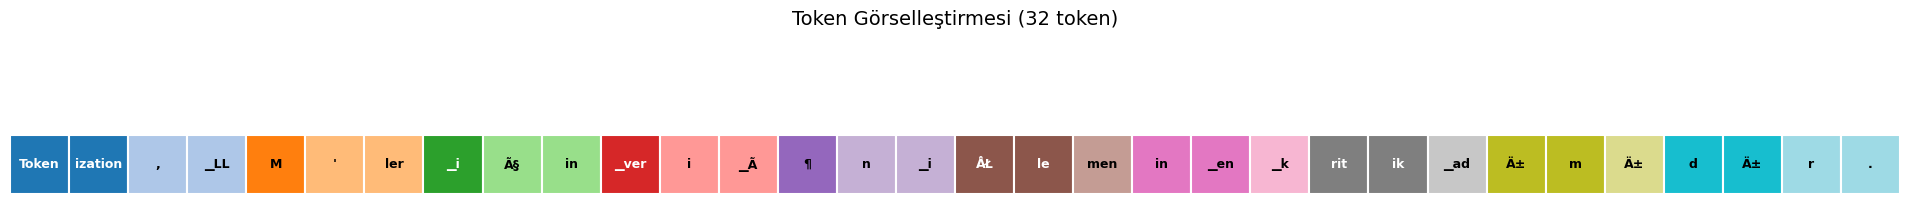

Token listesi:
    0. 'Token'
    1. 'ization'
    2. ','
    3. 'ĠLL'
    4. 'M'
    5. '''
    6. 'ler'
    7. 'Ġi'
    8. 'Ã§'
    9. 'in'
   10. 'Ġver'
   11. 'i'
   12. 'ĠÃ'
   13. '¶'
   14. 'n'
   15. 'Ġi'
   16. 'ÅŁ'
   17. 'le'
   18. 'men'
   19. 'in'
   20. 'Ġen'
   21. 'Ġk'
   22. 'rit'
   23. 'ik'
   24. 'Ġad'
   25. 'Ä±'
   26. 'm'
   27. 'Ä±'
   28. 'd'
   29. 'Ä±'
   30. 'r'
   31. '.'


In [ ]:
# ============================================================
# TOKEN GÖRSELLEŞTİRME FONKSİYONU
# ============================================================

def visualize_tokenization(text: str, tokenizer, max_length: int = 50):
    """
    Tokenization sonucunu renkli kutularla görselleştirir.

    Parametreler:
        text:       Girdi metni
        tokenizer:  Hugging Face tokenizer
        max_length: Maksimum token sayısı
    """

    # Token'ları al
    tokens = tokenizer.tokenize(text)[:max_length]

    # Benzersiz renkler oluştur
    colors = plt.cm.tab20(np.linspace(0, 1, len(tokens)))

    # Grafik oluştur
    fig, ax = plt.subplots(figsize=(max(12, len(tokens) * 0.6), 2.5))

    # Her token için bir renkli kutu çiz
    for i, (token, color) in enumerate(zip(tokens, colors)):
        # token içindeki özel karakterleri (Ġ gibi) daha okunabilir yap
        display_token = token.replace('Ġ', '▁')  # GPT-2'nin space karakteri

        # Dikdörtgen çiz (x, y, width, height)
        rect = plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='white', linewidth=1.5)
        ax.add_patch(rect)

        # Token metnini kutunun ortasına yaz
        ax.text(i + 0.5, 0.5, display_token,
                ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if np.mean(color[:3]) < 0.5 else 'black')

    # Eksen ayarları
    ax.set_xlim(0, len(tokens))
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')  # eksenleri gizle

    plt.suptitle(f"Token Görselleştirmesi ({len(tokens)} token)", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

    # Token listesini de yazdır
    print("Token listesi:")
    for i, t in enumerate(tokens):
        print(f"  {i:3d}. '{t}'")


# Test
test_text = "Tokenization, LLM'ler için veri ön işlemenin en kritik adımıdır."
visualize_tokenization(test_text, tokenizer)

---
## 10. Özet ve Önemli Noktalar

| Adım | Ne Yaparız? | Neden Önemli? |
|------|-------------|---------------|
| **Metin Temizleme** | HTML, URL, emoji, fazla boşluk temizliği | Vocabulary şişmesini önler, kaliteyi artırır |
| **Tokenization** | Metni token'lara ayırma (BPE/WordPiece) | Modelin anlayacağı sayısal forma dönüştürme |
| **Padding** | Kısa metinleri doldurma | Batch işleme için eşit boyut |
| **Truncation** | Uzun metinleri kesme | Context window sınırını aşmamak için |
| **Attention Mask** | Gerçek/padding token'larını ayırma | Modelin padding'i görmezden gelmesi |
| **Instruction Format** | Veriyi şablona yerleştirme | Modelin görevi anlaması için |

### Pratik Tavsiyeler:
- **Maksimum uzunluk** seçerken veri setinizin %95'ini kapsayacak bir değer seçin
- **Padding** her zaman attention_mask ile kullanın
- **Instruction formatı** modelin eğitildiği formatta olmalıdır
- **Tokenizer** modelle uyumlu olmalıdır (aynı modelin tokenizer'ını kullanın)
- **Veri kalitesi** her şeyden önemlidir: temiz, tutarlı ve doğru veri kullanın